# Exploratory Data Analysis & Feature Engineering
## Air Quality Prediction in Houston, TX (COSC 4368 Final Project)

What's going on here:
1. Explore the dataset we built in data collection notebook
2. Visualize distributions, correlations, trends
3. Engineer features (lagged values, rolling averages, etc.)
4. Saves the final feature-engineered dataset for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# load processed data from data collection notebook
df = pd.read_csv('data/processed/houston_aqi_weather_combined.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Dataset shape: (1370, 42)
Date range: 2022-01-01 to 2025-10-01


,Date,AQI,Category,Number of Sites Reporting,PM25_mean,PM25_max,Ozone_mean,Ozone_max,SO2_mean,SO2_max,...,relative_humidity_2m_min,relative_humidity_2m_mean,pressure_msl_mean,cloud_cover_mean,day_of_week,month,day_of_year,is_weekend,season,is_holiday
0,2022-01-01,64,Moderate,19,15.321094,50.1,0.019559,0.031,0.195259,6.1,...,55,82,1005.8,92,5,1,1,1,0,1
1,2022-01-02,38,Good,20,4.174053,26.2,0.027297,0.034,0.166786,0.8,...,40,56,1022.7,38,6,1,2,1,0,0
2,2022-01-03,51,Moderate,20,7.471324,30.0,0.014856,0.040,0.613545,2.8,...,37,52,1031.7,0,0,1,3,0,0,0
3,2022-01-04,65,Moderate,20,11.196814,33.0,0.026825,0.044,0.667277,4.6,...,46,64,1022.7,34,1,1,4,0,0,0
4,2022-01-05,77,Moderate,20,7.710880,52.0,0.024761,0.045,0.681042,10.7,...,53,83,1013.7,12,2,1,5,0,0,0


## 1. AQI Distribution & Overview

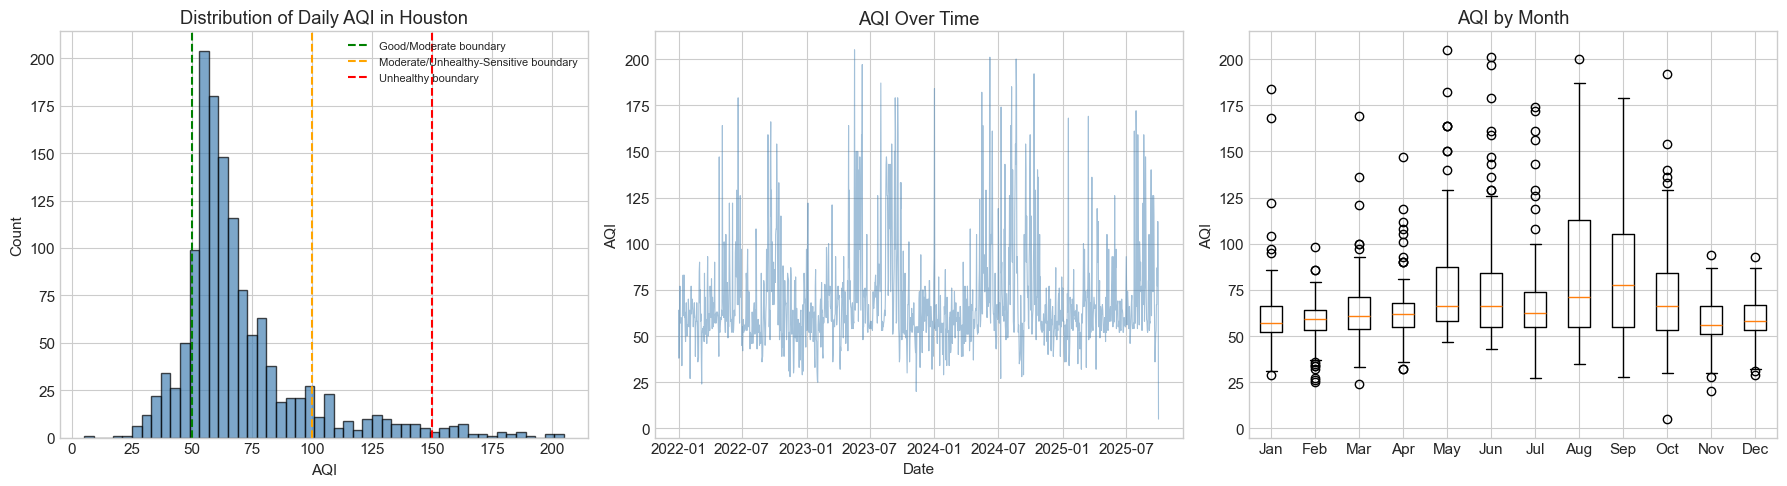

Saved: eda_aqi_overview.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AQI distribution
axes[0].hist(df['AQI'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Daily AQI in Houston')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Count')
axes[0].axvline(x=50, color='green', linestyle='--', label='Good/Moderate boundary')
axes[0].axvline(x=100, color='orange', linestyle='--', label='Moderate/Unhealthy-Sensitive boundary')
axes[0].axvline(x=150, color='red', linestyle='--', label='Unhealthy boundary')
axes[0].legend(fontsize=8)

# AQI over time
axes[1].plot(df['Date'], df['AQI'], alpha=0.5, linewidth=0.8, color='steelblue')
axes[1].set_title('AQI Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('AQI')

# AQI by month (boxplot)
monthly_data = [df[df['month'] == m]['AQI'].values for m in range(1, 13)]
bp = axes[2].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[2].set_title('AQI by Month')
axes[2].set_ylabel('AQI')

plt.tight_layout()
plt.savefig('data/processed/eda_aqi_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_aqi_overview.png")

## 2. AQI Category Breakdown

AQI Category counts:
Category
Moderate                          1046
Good                               175
Unhealthy for Sensitive Groups     113
Unhealthy                           34
Very Unhealthy                       2
Name: count, dtype: int64



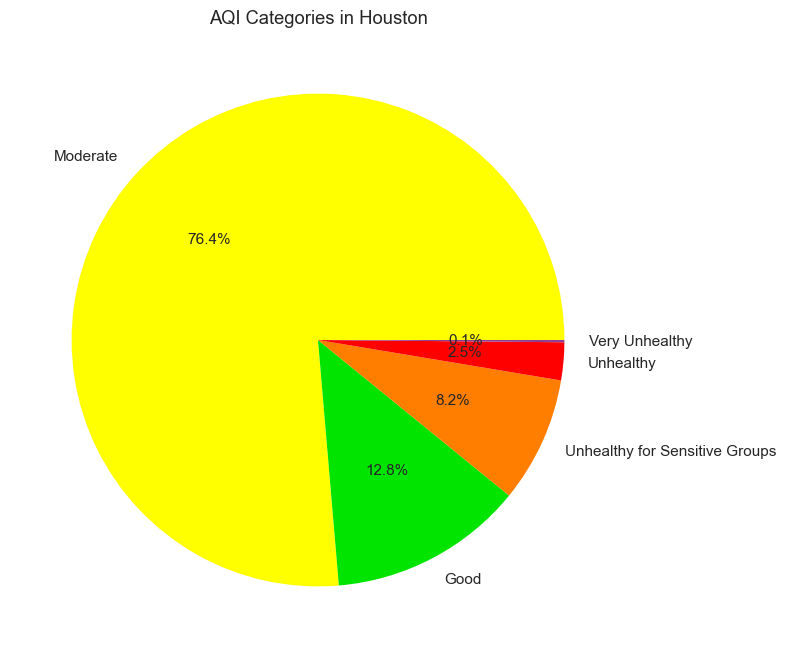

In [3]:
# what categories do we see?
if 'Category' in df.columns:
    cat_counts = df['Category'].value_counts()
    print("AQI Category counts:")
    print(cat_counts)
    print()
    
    # quick pie chart
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = {'Good': '#00e400', 'Moderate': '#ffff00', 
              'Unhealthy for Sensitive Groups': '#ff7e00',
              'Unhealthy': '#ff0000', 'Very Unhealthy': '#8f3f97',
              'Hazardous': '#7e0023'}
    cat_colors = [colors.get(c, '#cccccc') for c in cat_counts.index]
    ax.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', colors=cat_colors)
    ax.set_title('AQI Categories in Houston')
    plt.savefig('data/processed/eda_aqi_categories.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No Category column found")

## 3. Day of Week and Weekend Effects

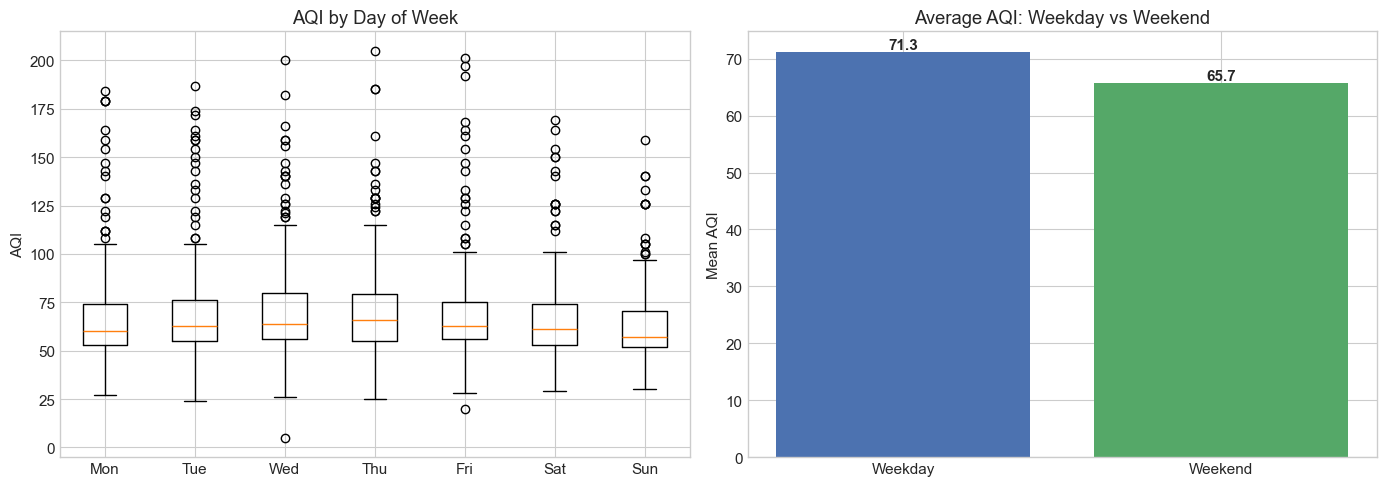

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AQI by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_data = [df[df['day_of_week'] == d]['AQI'].values for d in range(7)]
axes[0].boxplot(dow_data, labels=day_names)
axes[0].set_title('AQI by Day of Week')
axes[0].set_ylabel('AQI')

# weekend vs weekday
weekend_means = df.groupby('is_weekend')['AQI'].mean()
axes[1].bar(['Weekday', 'Weekend'], weekend_means.values, color=['#4c72b0', '#55a868'])
axes[1].set_title('Average AQI: Weekday vs Weekend')
axes[1].set_ylabel('Mean AQI')
for i, v in enumerate(weekend_means.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/eda_day_effects.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Heatmap

Correlation with AQI:
Ozone_max                     0.776579
Ozone_mean                    0.592182
PM25_mean                     0.494303
shortwave_radiation_sum       0.385630
Temp_max                      0.378946
NO2_max                       0.366362
temperature_2m_max            0.353752
apparent_temperature_max      0.343842
Temp_mean                     0.326231
temperature_2m_mean           0.306795
PM25_max                      0.292748
CO_mean                       0.285668
apparent_temperature_min      0.247073
NO2_mean                      0.240154
temperature_2m_min            0.232820
CO_max                        0.218968
season                        0.199563
SO2_mean                      0.130096
SO2_max                       0.129519
Wind_max                      0.125770
month                         0.098861
is_holiday                    0.033247
RH_mean                      -0.006163
Wind_mean                    -0.007204
relative_humidity_2m_max     -0.016673
win

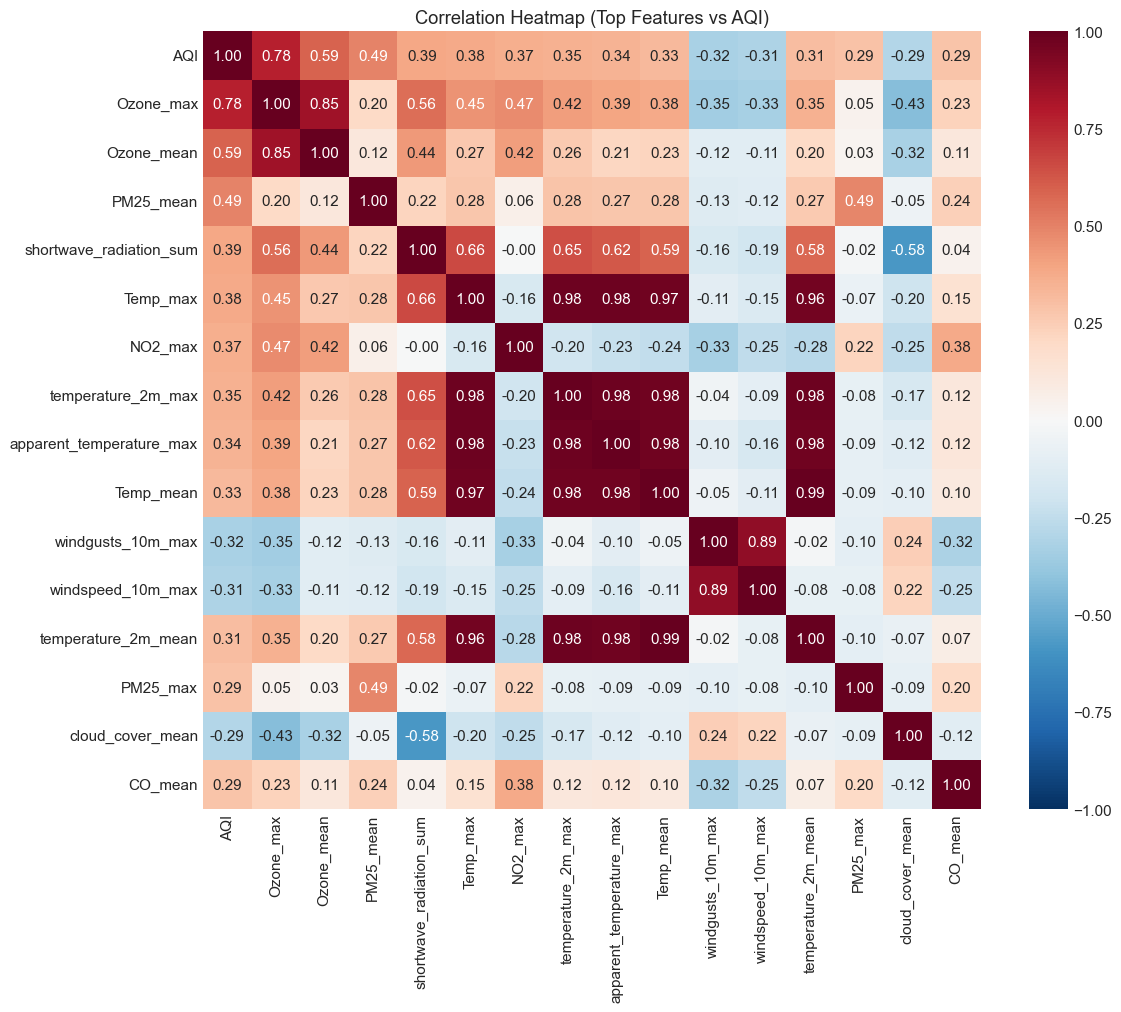

In [5]:
# pick numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# if there are too many columns, just pick the important ones
key_cols = [c for c in numeric_df.columns if c not in ['day_of_year']]

# compute correlation with AQI
aqi_corrs = numeric_df[key_cols].corr()['AQI'].drop('AQI').sort_values(ascending=False)
print("Correlation with AQI:")
print(aqi_corrs.to_string())
print()

# full heatmap (might be big, limit to top correlating features)
top_features = aqi_corrs.abs().nlargest(15).index.tolist()
top_features = ['AQI'] + [f for f in top_features if f != 'AQI']

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = numeric_df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Top Features vs AQI)')
plt.tight_layout()
plt.savefig('data/processed/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Weather vs AQI Scatter Plots

Weather columns available: ['Wind_mean', 'Wind_max', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'rain_sum', 'windspeed_10m_max', 'windgusts_10m_max', 'winddirection_10m_dominant', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean', 'pressure_msl_mean', 'cloud_cover_mean']


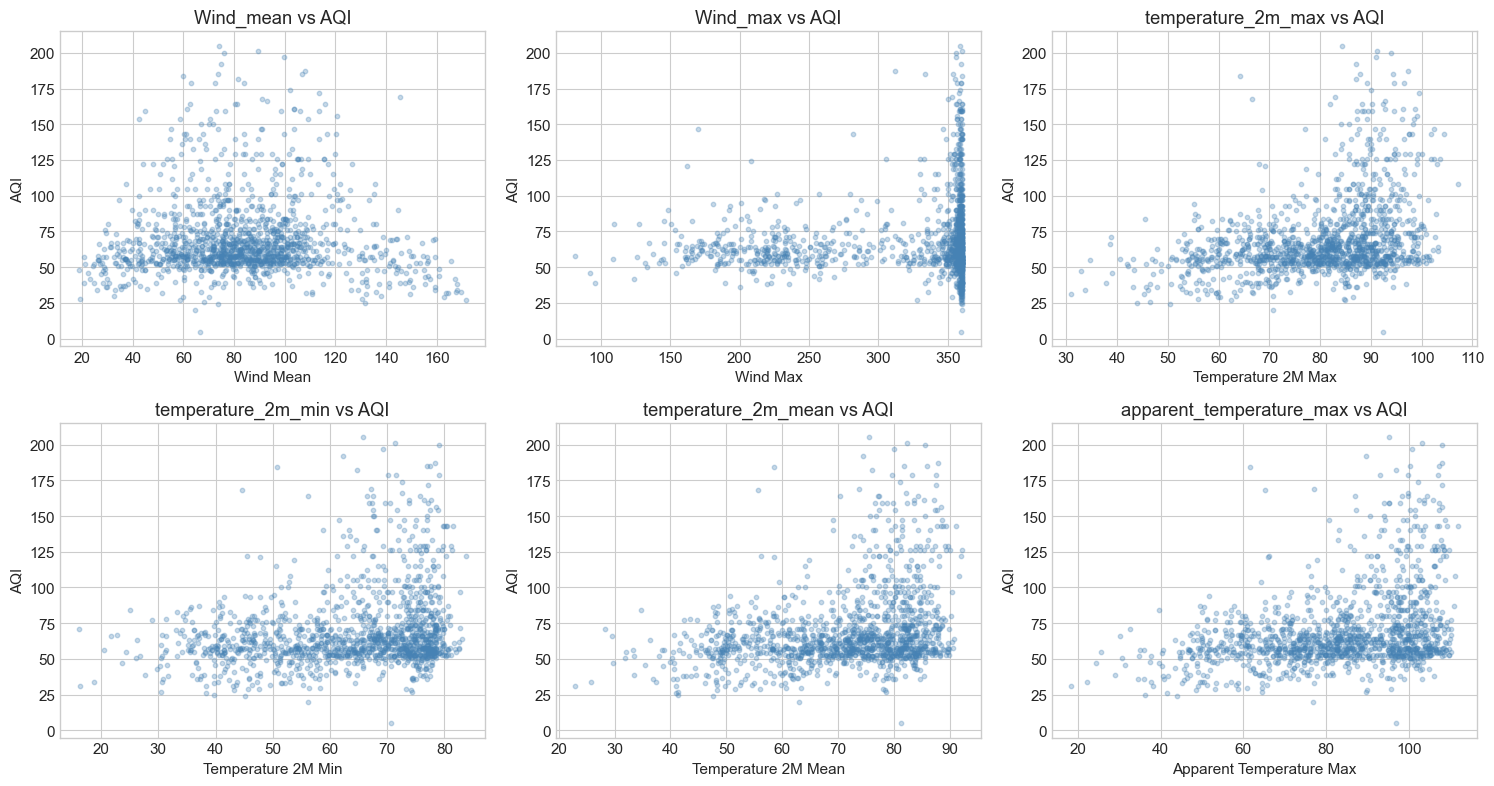

In [6]:
# check which weather columns we have
weather_cols = [c for c in df.columns if any(x in c.lower() for x in 
    ['temperature', 'wind', 'humid', 'precip', 'pressure', 'cloud', 'rain'])]
print(f"Weather columns available: {weather_cols}")

# pick up to 6 for scatter plots
scatter_cols = weather_cols[:6]

if scatter_cols:
    n_plots = len(scatter_cols)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    for i, col in enumerate(scatter_cols):
        axes[i].scatter(df[col], df['AQI'], alpha=0.3, s=10, color='steelblue')
        axes[i].set_xlabel(col.replace('_', ' ').title())
        axes[i].set_ylabel('AQI')
        axes[i].set_title(f'{col} vs AQI')
    
    # hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('data/processed/eda_weather_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No weather columns found")

## 6. Pollutant Trends Over Time

Pollutant mean columns: ['PM25_mean', 'Ozone_mean', 'SO2_mean', 'CO_mean', 'NO2_mean']


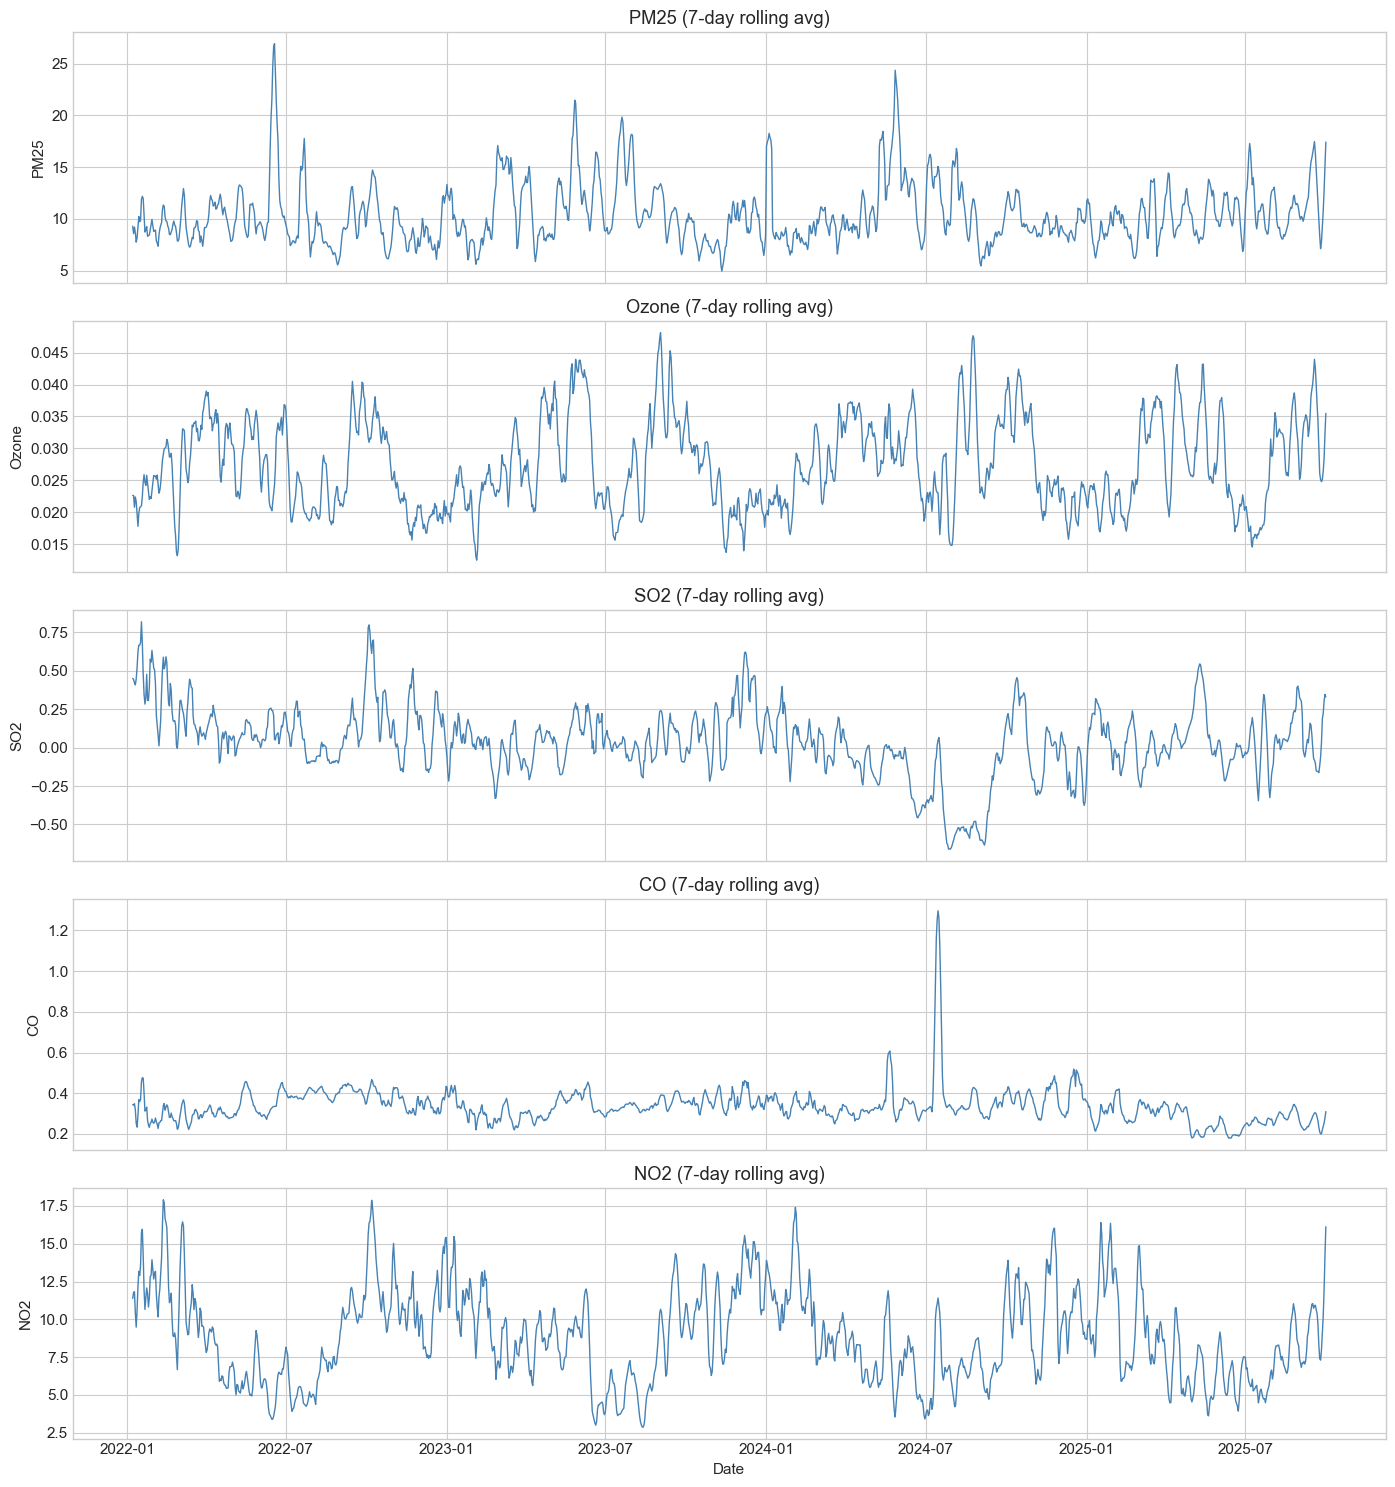

In [7]:
pollutant_cols = [c for c in df.columns if any(p in c for p in ['PM25', 'Ozone', 'SO2', 'CO', 'NO2']) and 'mean' in c]
print(f"Pollutant mean columns: {pollutant_cols}")

if pollutant_cols:
    fig, axes = plt.subplots(len(pollutant_cols), 1, figsize=(14, 3*len(pollutant_cols)), sharex=True)
    if len(pollutant_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(pollutant_cols):
        # rolling 7-day average for smoother visualization
        rolling = df.set_index('Date')[col].rolling(7).mean()
        axes[i].plot(rolling.index, rolling.values, linewidth=1, color='steelblue')
        axes[i].set_ylabel(col.replace('_mean', ''))
        axes[i].set_title(f'{col.replace("_mean", "")} (7-day rolling avg)')
    
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig('data/processed/eda_pollutant_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No pollutant columns found")

## 7. Feature Engineering

Create lagged features, rolling statistics, and rate-of-change features.
This is gonna give predictive power for the time-series model

In [ ]:
# make a copy so we don't mess up the original
feat_df = df.copy()

#    LAG FEATURES 
# the most important ones: what was AQI yesterday? 2 days ago? a week ago?
lag_days = [1, 2, 3, 7, 14]
for lag in lag_days:
    feat_df[f'AQI_lag_{lag}'] = feat_df['AQI'].shift(lag)

# also lag the pollutants if they exist
for col in [c for c in feat_df.columns if '_mean' in c and any(p in c for p in ['PM25', 'Ozone', 'NO2'])]:
    feat_df[f'{col}_lag_1'] = feat_df[col].shift(1)
    feat_df[f'{col}_lag_3'] = feat_df[col].shift(3)

print("Created lag features")

#    ROLLING AVERAGES
# captures recent trend better than just yesterday's value
for window in [3, 7, 14, 30]:
    feat_df[f'AQI_rolling_mean_{window}d'] = feat_df['AQI'].shift(1).rolling(window).mean()
    feat_df[f'AQI_rolling_std_{window}d'] = feat_df['AQI'].shift(1).rolling(window).std()

print("Created rolling average features")

#     RATE OF CHANGE
# is AQI trending up or down?
feat_df['AQI_change_1d'] = feat_df['AQI'].shift(1) - feat_df['AQI'].shift(2)
feat_df['AQI_change_3d'] = feat_df['AQI'].shift(1) - feat_df['AQI'].shift(4)
feat_df['AQI_change_7d'] = feat_df['AQI'].shift(1) - feat_df['AQI'].shift(8)

print("Created rate of change features")

#     CYCLICAL ENCODING 
# encode day_of_week and month as sin/cos so the model knows Sunday is close to Monday
feat_df['dow_sin'] = np.sin(2 * np.pi * feat_df['day_of_week'] / 7)
feat_df['dow_cos'] = np.cos(2 * np.pi * feat_df['day_of_week'] / 7)
feat_df['month_sin'] = np.sin(2 * np.pi * feat_df['month'] / 12)
feat_df['month_cos'] = np.cos(2 * np.pi * feat_df['month'] / 12)
feat_df['doy_sin'] = np.sin(2 * np.pi * feat_df['day_of_year'] / 365)
feat_df['doy_cos'] = np.cos(2 * np.pi * feat_df['day_of_year'] / 365)

print("Created cyclical encoding features")

#     ROLLING WEATHER FEATURES 
weather_roll_cols = [c for c in feat_df.columns if 'temperature' in c.lower() and 'mean' in c.lower()]
for col in weather_roll_cols[:2]:  # just do mean temp
    feat_df[f'{col}_rolling_3d'] = feat_df[col].shift(1).rolling(3).mean()

print("Created rolling weather features")

print(f"\nFeature count: {feat_df.shape[1]} columns")

Created lag features
Created rolling average features
Created rate of change features
Created cyclical encoding features
Created rolling weather features

Feature count: 71 columns


## 8. Drop Rows Lost to Lagging & Final Cleanup

In [9]:
# the lag and rolling features create NaN at the beginning of the dataset
# we need to drop those rows
rows_before = len(feat_df)
feat_df = feat_df.dropna()
rows_after = len(feat_df)
print(f"Dropped {rows_before - rows_after} rows due to lag/rolling NaN (expected, ~30 rows)")
print(f"Final dataset: {feat_df.shape}")

# drop non-numeric and non-useful columns for modeling
# keep Date for time-based train/test split, but the model won't use it as a feature
cols_to_drop = ['Category', 'Defining Parameter']
cols_to_drop = [c for c in cols_to_drop if c in feat_df.columns]
feat_df = feat_df.drop(columns=cols_to_drop)

print(f"After dropping text columns: {feat_df.shape}")
print(f"\nAll columns:")
for i, col in enumerate(feat_df.columns):
    print(f"  {i+1}. {col}")

Dropped 30 rows due to lag/rolling NaN (expected, ~30 rows)
Final dataset: (1340, 71)
After dropping text columns: (1340, 70)

All columns:
  1. Date
  2. AQI
  3. Number of Sites Reporting
  4. PM25_mean
  5. PM25_max
  6. Ozone_mean
  7. Ozone_max
  8. SO2_mean
  9. SO2_max
  10. CO_mean
  11. CO_max
  12. NO2_mean
  13. NO2_max
  14. Temp_mean
  15. Temp_max
  16. Wind_mean
  17. Wind_max
  18. RH_mean
  19. RH_max
  20. temperature_2m_max
  21. temperature_2m_min
  22. temperature_2m_mean
  23. apparent_temperature_max
  24. apparent_temperature_min
  25. precipitation_sum
  26. rain_sum
  27. windspeed_10m_max
  28. windgusts_10m_max
  29. winddirection_10m_dominant
  30. shortwave_radiation_sum
  31. relative_humidity_2m_max
  32. relative_humidity_2m_min
  33. relative_humidity_2m_mean
  34. pressure_msl_mean
  35. cloud_cover_mean
  36. day_of_week
  37. month
  38. day_of_year
  39. is_weekend
  40. season
  41. is_holiday
  42. AQI_lag_1
  43. AQI_lag_2
  44. AQI_lag_3
  45. 

## 9. Save the Feature-Engineered Dataset

In [10]:
output_path = 'data/processed/houston_aqi_features_final.csv'
feat_df.to_csv(output_path, index=False)
print(f"Saved feature-engineered dataset to {output_path}")
print(f"Shape: {feat_df.shape}")
print(f"Date range: {feat_df['Date'].min()} to {feat_df['Date'].max()}")

Saved feature-engineered dataset to data/processed/houston_aqi_features_final.csv
Shape: (1340, 70)
Date range: 2022-01-31 00:00:00 to 2025-10-01 00:00:00
